In [1]:
import torch
from torch import nn
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor, v2
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import seaborn as sns

from torchmetrics import Accuracy
from torchmetrics import ConfusionMatrix
from tqdm.std import tqdm

In [2]:
normalize = transforms.Normalize(
    mean=[0.4467, 0.4398, 0.4066],
    std=[0.2603, 0.2566, 0.2713]
)

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(degrees=15),
    transforms.RandomCrop(96, padding=8),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    normalize
])
test_transform = transforms.Compose([
    transforms.ToTensor(),
    normalize
])

train_data = datasets.STL10(root='data', split='train', download=True, transform=train_transform)
test_data  = datasets.STL10(root='data', split='test',  download=True, transform=test_transform)
unlabeled_data = datasets.STL10(root='data', split='unlabeled', download=True, transform=test_transform)

In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [4]:
SUBSET=100000
unlabeled_subset = torch.utils.data.Subset(unlabeled_data, range(SUBSET))
len(train_data), len(test_data), len(unlabeled_subset)

(5000, 8000, 100000)

In [5]:
image, label = train_data[0]
image, label

(tensor([[[-1.7161, -1.7161, -1.7161,  ..., -1.7161, -1.7161, -1.7161],
          [-1.7161, -1.7161, -1.7161,  ..., -1.7161, -1.7161, -1.7161],
          [-1.7161, -1.7161, -1.7161,  ..., -1.7161, -1.7161, -1.7161],
          ...,
          [-1.7161,  0.1520,  0.3780,  ..., -1.7161, -1.7161, -1.7161],
          [-1.7161,  0.0918,  0.2123,  ..., -1.7161, -1.7161, -1.7161],
          [-1.7161, -0.1945, -0.1794,  ..., -1.7161, -1.7161, -1.7161]],
 
         [[-1.7140, -1.7140, -1.7140,  ..., -1.7140, -1.7140, -1.7140],
          [-1.7140, -1.7140, -1.7140,  ..., -1.7140, -1.7140, -1.7140],
          [-1.7140, -1.7140, -1.7140,  ..., -1.7140, -1.7140, -1.7140],
          ...,
          [-1.7140,  0.0130,  0.3339,  ..., -1.7140, -1.7140, -1.7140],
          [-1.7140, -0.0328,  0.1811,  ..., -1.7140, -1.7140, -1.7140],
          [-1.7140, -0.2927, -0.1857,  ..., -1.7140, -1.7140, -1.7140]],
 
         [[-1.4987, -1.4987, -1.4987,  ..., -1.4987, -1.4987, -1.4987],
          [-1.4987, -1.4987,

In [6]:
classes_names = train_data.classes
classes_names

['airplane',
 'bird',
 'car',
 'cat',
 'deer',
 'dog',
 'horse',
 'monkey',
 'ship',
 'truck']

In [7]:
image.shape

torch.Size([3, 96, 96])

In [12]:
mean = torch.tensor([0.4467, 0.4398, 0.4066]).view(3, 1, 1)
std  = torch.tensor([0.2603, 0.2566, 0.2713]).view(3, 1, 1)

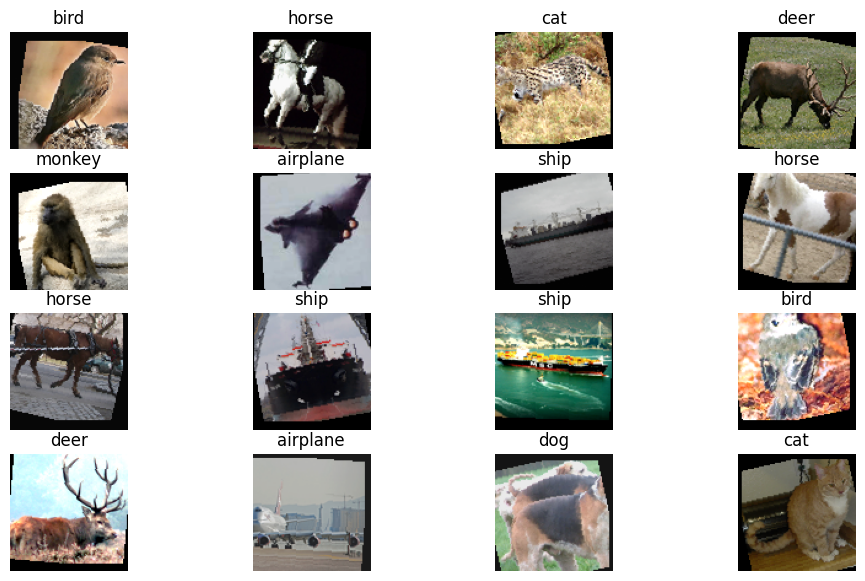

In [13]:
fig = plt.figure(figsize=(12,7))
rows, cols = 4, 4

for i in range(1, rows*cols+1):
    random_idx = torch.randint(1, len(train_data), size=[1]).item()
    img,label = train_data[random_idx]
    
    img = img*std+mean
    img = img.clamp(0, 1) 

    fig.add_subplot(rows, cols, i);
    plt.imshow(img.permute(1,2,0));
    plt.title(classes_names[label]);
    plt.axis(False);

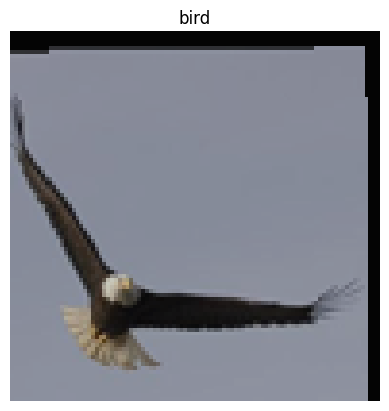

In [14]:
for i in range(1, rows*cols+1):
    random_idx = torch.randint(1, len(train_data), size=[1]).item()
    img,label = train_data[random_idx]
    img = img*std+mean
    img = img.clamp(0, 1)
    fig.add_subplot(rows, cols, i);
    plt.imshow(img.permute(1,2,0));
    plt.title(classes_names[label]);
    plt.axis(False);

In [15]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_dataloader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, drop_last=True, num_workers=4, pin_memory=True)
test_dataloader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, drop_last=True, num_workers=4, pin_memory=True)
unlabeled_dataloader = DataLoader(unlabeled_subset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False, num_workers=4, pin_memory=True)

len(train_dataloader), len(test_dataloader), len(unlabeled_dataloader)

(156, 250, 3125)

In [16]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels)
        )
        self.shortcut = (nn.Conv2d(in_channels, out_channels, kernel_size=1) 
                         if in_channels != out_channels 
                         else nn.Identity())
        
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(self.block(x) + self.shortcut(x))

In [ ]:
class STL10Model(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.conv_block = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            ResidualBlock(32),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            ResidualBlock(64),
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            ResidualBlock(128),
        )

        self.linear_block = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(128,10),
        )

    def forward(self, x):
        return self.linear_block(self.conv_block(x))

class STL10Model(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.conv_block = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            ResidualBlock(32, 32),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            ResidualBlock(64, 64),
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            ResidualBlock(128, 128),
        )

        self.linear_block = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.linear_block(self.conv_block(x))

model = STL10Model().to(device)

TypeError: ResidualBlock.__init__() missing 1 required positional argument: 'out_channels'

In [ ]:
dummy = torch.rand([1,3,96,96]).to(device)
print(model.conv_block(dummy).shape)

In [ ]:
acc = Accuracy(task='multiclass', num_classes=len(classes_names))
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.001, weight_decay=1e-4)

In [ ]:
acc.to(device)

In [ ]:
MAX_EPOCHS = 100
best_loss = float('inf')
patience = 8
counter = 0

for epoch in range(1, MAX_EPOCHS + 1):
    print(f'\nEpoch {epoch}/{MAX_EPOCHS}\n-----------')
    
    # Train
    model.train()
    train_loss = 0

    for X, y in tqdm(train_dataloader):
        X, y = X.to(device), y.to(device)
        
        optimizer.zero_grad()
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()

    train_loss /= len(train_dataloader)

    # Eval
    model.eval()
    test_loss = 0

    with torch.inference_mode():
        for X_test, y_test in test_dataloader:
            X_test, y_test = X_test.to(device), y_test.to(device)
            test_pred = model(X_test)
            test_loss += loss_fn(test_pred, y_test).item()
            acc.update(test_pred.argmax(dim=1), y_test)

        test_loss /= len(test_dataloader)
        test_acc = acc.compute()
        acc.reset()

    print(f'Train loss {train_loss:.4f} | Test loss {test_loss:.4f} | Test acc {test_acc * 100:.2f}%')

    # Early stopping + checkpoint
    if test_loss < best_loss:
        best_loss = test_loss
        counter = 0
        torch.save({
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'epoch': epoch,
            'loss': best_loss,
        }, 'model_params/best_model.pth')
        print(f'✓ Saved best model (loss: {best_loss:.4f})')
    else:
        counter += 1
        print(f'No improvement {counter}/{patience}')
        if counter >= patience:
            print(f'Early stopping at epoch {epoch}')
            break

In [ ]:
checkpoint = torch.load('model_params/best_model.pth')
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

In [ ]:
CONFIDENCE_THRESHOLD = 0.90

pseudo_images = []
pseudo_labels = []

model.eval()
with torch.inference_mode():
    for X, _ in tqdm(unlabeled_dataloader):
        X = X.to(device)
        probs = torch.softmax(model(X), dim=1)
        confidence, predicted = probs.max(dim=1)

        mask = confidence >= CONFIDENCE_THRESHOLD
        pseudo_images.append(X[mask].cpu())
        pseudo_labels.append(predicted[mask].cpu())

pseudo_images = torch.cat(pseudo_images)
pseudo_labels = torch.cat(pseudo_labels)

print(f'Pseudo-labeled images: {len(pseudo_images)} / {len(unlabeled_data)}')

In [ ]:
from torch.utils.data import TensorDataset, ConcatDataset

pseudo_dataset = TensorDataset(pseudo_images, pseudo_labels.long())

class LabelToTensor(torch.utils.data.Dataset):
    def __init__(self, dataset):
        self.dataset = dataset
    def __len__(self):
        return len(self.dataset)
    def __getitem__(self, idx):
        img, label = self.dataset[idx]
        return img, torch.tensor(label)

combined_dataset = ConcatDataset([LabelToTensor(train_data), pseudo_dataset])
combined_dataloader = DataLoader(combined_dataset, batch_size=32, shuffle=True, drop_last=True)

In [ ]:
best_loss = float('inf')
patience = 8
counter = 0

epochs = 0

while True:
    epochs += 1
    print(f'\nEpoch {epochs}\n-----------')
    train_loss = 0
    model.train()

    for batch, (X, y) in tqdm(enumerate(combined_dataloader)):
        X, y = X.to(device), y.to(device)
        y_pred = model(X)

        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    train_loss /= len(train_dataloader)

    test_loss, test_acc = 0, 0
    model.eval()

    with torch.inference_mode():
        for X_test, y_test in test_dataloader:
            X_test, y_test = X_test.to(device), y_test.to(device)

            test_pred = model(X_test)

            test_loss += loss_fn(test_pred, y_test)
            acc.update(test_pred.argmax(dim=1), y_test)

        test_loss /= len(test_dataloader)
        test_acc = acc.compute()
        acc.reset()

    print(f'\nTrain loss {train_loss:.4f} | Test loss {test_loss:.4f} | Test acc {test_acc * 100:.2f}%')  

    if test_loss < best_loss:
        best_loss = test_loss
        torch.save({
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'epoch': epochs,
            'loss': best_loss,
        }, 'model_params/best_model.pth')
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print('Early stopping')
            break

In [ ]:
img, label = test_data[250]
img = img.unsqueeze(0).to(device)

with torch.inference_mode():
    pred = model(img)
    pred_class = pred.argmax(dim=1).item()

print(f'Predicted: {classes_names[pred_class]} | Actual: {classes_names[label]}')

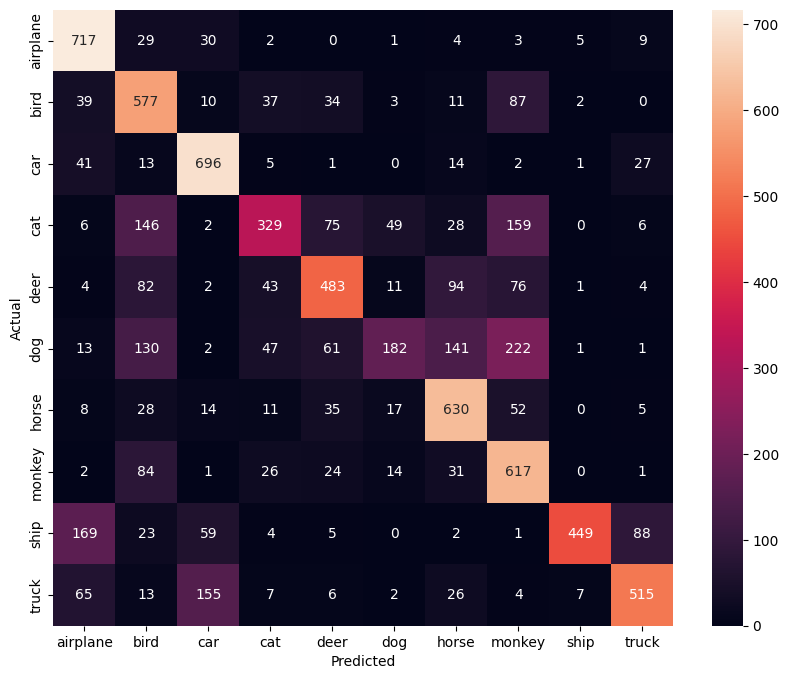

In [25]:
confmat = ConfusionMatrix(task='multiclass', num_classes=10).to(device)

model.eval()
with torch.inference_mode():
    for X_test, y_test in test_dataloader:
        X_test, y_test = X_test.to(device), y_test.to(device)
        confmat.update(model(X_test).argmax(dim=1), y_test)

matrix = confmat.compute().cpu().numpy()

plt.figure(figsize=(10, 8))
sns.heatmap(matrix, annot=True, fmt='g',
            xticklabels=classes_names,
            yticklabels=classes_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# The model does a good job of distinguishing between vehicles and animals, but it struggles to distinguish between different types of animals within the same category. This is an issue for CNNs without transfer learning — there isn’t enough data to learn the subtle differences between similar classes.

# Adding a learning rate scheduler resulted in only a negligible improvement in test accuracy (69.71% → 69.82%), indicating that further gains are unlikely to come from scheduler tuning and that the current architecture may have reached its performance limit.

# Tried adding pseudo-labeling pipeline using unlabeled STL10 split, but acc did not improved
